# Installation and Quick Start

## Installation

To install MieNet, clone the git repository and install it:

In [ ]:
git clone https://github.com/d-attaway/mienet.git
cd mienet
pip install -e .

To run the AI models, you need to download the pre-trained models from [Zenodo](https://zenodo.org/records/20346256):

In [ ]:
from mienet import MieNet

# set up mienet class
# to choose where the data are saved set default_data_location = 'path/to/folder/'
ma = MieNet(default_data_location = None)

# download data
ma.download_models()

## Quick Start

To calculate the opacities of heterogenous particles, all you have to provide are the wavelengths, radii, and the volume mixing ratios (VMRs) of the cloud particles. One VMR per radius is expected

In [5]:
import numpy as np
from mienet import MieNet

# example values
wavelengths = np.logspace(1, 2, 100)  # wavelength range in micron
radii = np.logspace(-2, 2, 100)  # particle size in micron
vmrs = {
    'SiO2': 0.8 * np.ones_like(radii),
    'Fe': 0.2 * np.ones_like(radii),
}

# set up mienet class
ma = MieNet()

# calculate opacities using the ai model
qext_ai, qsca_ai, asym_ai = ma.ai_efficiencies(wavelengths, radii, vmrs)

# calcualte opaciteis using full calculations
qext_full, qsca_full, asym_full = ma.efficiencies(wavelengths, radii, vmrs)

310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


Here a plot of the results:

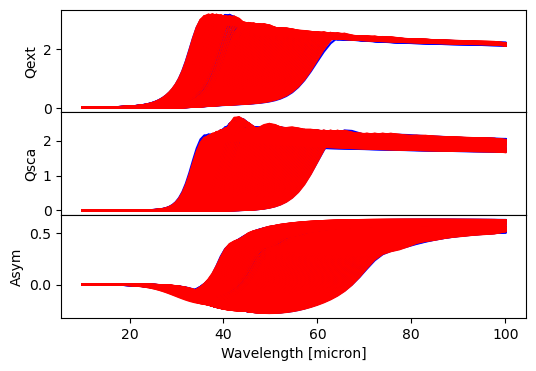

In [6]:
import matplotlib.pyplot as plt

# plot results
fig, ax = plt.subplots(3, 1, figsize=(6,4))
ax[0].plot(wavelengths, qext_ai, color='blue', label='AI')
ax[0].plot(wavelengths, qext_full, color='red', label='Full')
ax[1].plot(wavelengths, qsca_ai, color='blue', label='AI')
ax[1].plot(wavelengths, qsca_full, color='red', label='Full')
ax[2].plot(wavelengths, asym_ai, color='blue', label='AI')
ax[2].plot(wavelengths, asym_full, color='red', label='Full')

# make a pretty plot
plt.subplots_adjust(hspace=0)
ax[0].set_ylabel('Qext')
ax[1].set_ylabel('Qsca')
ax[2].set_ylabel('Asym')
ax[2].set_xlabel('Wavelength [micron]')
plt.show()